# Proyecto: Mercado de Limones Argentinos
## Notebook 03 — Índice de Selección Adversa (ISA)
### Período: Enero 2023 — Marzo 2026
### Fecha de análisis: 15/06/2026
### Autor: Rodolfo Gabriel Riveros Lobos

---

## Objetivo del notebook

Construir un índice compuesto que sintetice los hallazgos 
de los Notebooks 01 y 02 en una métrica única por período, 
y utilizarla para narrar la evolución del mercado en relación 
a los eventos macroeconómicos identificados.

## Nota metodológica — alcance del "modelo"

Con n=7 períodos, no es posible realizar inferencia estadística 
robusta (regresión, correlación con significancia, análisis de 
lag/lead). Este notebook construye un **índice compuesto 
descriptivo**, no un modelo predictivo. Su valor es narrativo 
y diagnóstico: sintetiza múltiples señales dispersas en una 
sola métrica interpretable, siguiendo la lógica de índices 
compuestos utilizados por organismos económicos (ej. índice 
de confianza del consumidor).

* Cuando esta variable SUBE: antiguedad_mediaH1A → mercado tiene más selección adversa
* Cuando esta variable SUBE: pct_protocolo21H4A  → mercado tiene más selección adversa (cascada)
* La variable pct_jovenesH5 ->  NO LINEAL con el mercado, variable diadnostica aparte

### Librerias

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
from scipy import stats

# Configuración
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

RAW_PATH = Path('../data/raw')
PROCESSED_PATH = Path('../data/processed')

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### Reconstruir métricas base

In [3]:
def cargar_y_limpiar(filepath):
    nombre = Path(filepath).stem
    partes = nombre.split('_')
    anio = int(partes[1])
    mes = int(partes[2])
    periodo = f"{anio}-{mes:02d}"
    
    df = pd.read_csv(
        filepath,
        encoding='utf-8-sig',
        sep=',',
        low_memory=False,
        dtype={'automotor_tipo_codigo': str}
    )
    
    df = df[df['tramite_tipo'] != 'TRANSFERENCIA SUBASTADOS / AFF / CLASICOS'].copy()
    df = df.dropna(subset=['automotor_anio_modelo'])
    df['automotor_anio_modelo'] = pd.to_numeric(
        df['automotor_anio_modelo'], errors='coerce'
    ).astype('Int64')
    df = df[
        (df['automotor_anio_modelo'] >= 1950) &
        (df['automotor_anio_modelo'] <= anio)
    ].copy()
    
    df['antiguedad'] = anio - df['automotor_anio_modelo']
    df['periodo'] = periodo
    df['anio_archivo'] = anio
    
    bins = [0, 3, 7, 15, 25, 40, 75]
    labels = ['0-3 años', '4-7 años', '8-15 años',
              '16-25 años', '26-40 años', '41+ años']
    df['rango_antiguedad'] = pd.cut(
        df['antiguedad'],
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    
    return df

# Cargar todos los archivos
print("Cargando archivos...")
orden_periodos = [
    '2023-01', '2023-10', '2024-02',
    '2024-12', '2025-01', '2025-10', '2026-03'
]

dataframes = []
for filepath in sorted(RAW_PATH.glob('transferencias_*.csv')):
    df_mes = cargar_y_limpiar(filepath)
    dataframes.append(df_mes)
    print(f"  {df_mes['periodo'].iloc[0]} → {len(df_mes):,} registros")

df_total = pd.concat(dataframes, ignore_index=True)

# Optimización de memoria
categoricas = ['periodo', 'automotor_origen', 'rango_antiguedad']
for col in categoricas:
    df_total[col] = df_total[col].astype('category')

print(f"\nTotal: {len(df_total):,} registros")
print(f"Memoria: {df_total.memory_usage(deep=True).sum()/1024/1024:.1f} MB")

Cargando archivos...
  2023-01 → 132,129 registros
  2023-10 → 140,402 registros
  2024-02 → 105,408 registros
  2024-12 → 159,667 registros
  2025-01 → 169,213 registros
  2025-10 → 165,683 registros
  2026-03 → 153,351 registros

Total: 1,025,853 registros
Memoria: 1315.3 MB


### Optimización y selección de columnas

In [4]:
# Columnas necesarias para el índice
COLUMNAS_UTILES = [
    'periodo',
    'anio_archivo',
    'automotor_origen',
    'automotor_anio_modelo',
    'antiguedad',
    'rango_antiguedad'
]

df_total = df_total[COLUMNAS_UTILES].copy()

# Optimización de memoria
categoricas = ['periodo', 'automotor_origen', 'rango_antiguedad']
for col in categoricas:
    df_total[col] = df_total[col].astype('category')

memoria_final = df_total.memory_usage(deep=True).sum() / 1024 / 1024
print(f"Memoria optimizada: {memoria_final:.1f} MB")
print(f"Shape: {df_total.shape}")

Memoria optimizada: 28.4 MB
Shape: (1025853, 6)


## construcción de Métricas Base

In [5]:
# Métrica 1 — antigüedad media por período
antiguedad_periodo = (df_total
    .groupby('periodo', observed=True)['antiguedad']
    .mean()
    .round(4)
    .reset_index()
    .rename(columns={'antiguedad': 'antiguedad_media'}))

# Métrica 2 — participación Protocolo 21 por período
total_periodo = (df_total
    .groupby('periodo', observed=True)
    .size()
    .reset_index(name='total'))

proto21_periodo = (df_total[df_total['automotor_origen'] == 'Protocolo 21']
    .groupby('periodo', observed=True)
    .size()
    .reset_index(name='proto21'))

# Métrica 3 — participación vehículos 0-3 años (variable diagnóstica)
jovenes_periodo = (df_total
    .groupby('periodo', observed=True)
    .apply(lambda x: (x['rango_antiguedad'] == '0-3 años').sum() / len(x) * 100)
    .reset_index(name='pct_jovenes'))

# Consolidar en tabla de métricas
metricas = antiguedad_periodo.merge(total_periodo, on='periodo')
metricas = metricas.merge(proto21_periodo, on='periodo')
metricas = metricas.merge(jovenes_periodo, on='periodo')
metricas['pct_proto21'] = (metricas['proto21'] / metricas['total'] * 100).round(4)

# Orden cronológico
orden_periodos = [
    '2023-01', '2023-10', '2024-02',
    '2024-12', '2025-01', '2025-10', '2026-03'
]
metricas['periodo'] = pd.Categorical(
    metricas['periodo'],
    categories=orden_periodos,
    ordered=True
)
metricas = metricas.sort_values('periodo').reset_index(drop=True)

print("MÉTRICAS BASE")
print(metricas[['periodo', 'total', 'antiguedad_media', 
                 'pct_proto21', 'pct_jovenes']].to_string(index=False))

MÉTRICAS BASE
periodo  total  antiguedad_media  pct_proto21  pct_jovenes
2023-01 132129           14.2097      40.6640     6.868288
2023-10 140402            14.466      39.3378     8.224954
2024-02 105408           15.0518      38.9430     8.067699
2024-12 159667           13.3433      39.5348    10.155511
2025-01 169213           14.3858      40.4147     7.015418
2025-10 165683           13.9452      41.6669    10.214084
2026-03 153351           14.8066      41.9652     8.083416


---
## Construcción del Índice de Selección Adversa (ISA)

### Componentes

| Variable | Rol | Signo | Justificación |
|---|---|---|---|
| antiguedad_media | Componente principal | + | Mayor antigüedad = mayor retención de buenos autos |
| pct_proto21 | Componente secundario | + | Mayor P21 = mayor exposición a asimetría no verificable |
| pct_jovenes | Variable diagnóstica | — | No lineal, se usa para contextualizar, no para componer |

### Metodología de normalización

Se utiliza z-score para llevar ambas variables a escala común
(media = 0, desvío estándar = 1) antes de ponderar.

### Versiones del índice

**ISA_B (principal):** ponderación 70/30
Justificación: antiguedad_media tiene respaldo directo en 
Akerlof (1970). pct_proto21 es extensión derivada del modelo.

**ISA_C (robustez):** ponderación 50/50
Si el ranking de períodos es idéntico en ambas versiones, 
la ponderación no afecta las conclusiones (análisis de 
sensibilidad).

In [6]:
# Normalización por z-score
metricas['z_antiguedad'] = stats.zscore(metricas['antiguedad_media'])
metricas['z_proto21'] = stats.zscore(metricas['pct_proto21'])

# ISA versión B — 70/30 (principal)
metricas['ISA_B'] = (0.7 * metricas['z_antiguedad'] + 
                      0.3 * metricas['z_proto21']).round(4)

# ISA versión C — 50/50 (robustez)
metricas['ISA_C'] = (0.5 * metricas['z_antiguedad'] + 
                      0.5 * metricas['z_proto21']).round(4)

# Ranking por cada versión
metricas['rank_B'] = metricas['ISA_B'].rank(ascending=False).astype(int)
metricas['rank_C'] = metricas['ISA_C'].rank(ascending=False).astype(int)

# Verificación de robustez
ranking_identico = (metricas['rank_B'] == metricas['rank_C']).all()

print("ÍNDICE DE SELECCIÓN ADVERSA (ISA)")
print("="*65)
cols = ['periodo', 'z_antiguedad', 'z_proto21', 
        'ISA_B', 'rank_B', 'ISA_C', 'rank_C']
print(metricas[cols].to_string(index=False))
print("="*65)
print(f"\n¿Ranking idéntico entre ISA_B e ISA_C? → {ranking_identico}")

ÍNDICE DE SELECCIÓN ADVERSA (ISA)
periodo  z_antiguedad  z_proto21   ISA_B  rank_B   ISA_C  rank_C
2023-01     -0.202814   0.281516 -0.0575       4  0.0394       5
2023-10      0.288568  -0.950301 -0.0831       5 -0.3309       6
2024-02      1.411671  -1.317004  0.5931       2  0.0473       4
2024-12     -1.863886  -0.767321 -1.5349       7 -1.3156       7
2025-01      0.134807   0.049958  0.1094       3  0.0924       3
2025-10     -0.709916   1.213041 -0.1330       6  0.2516       2
2026-03      0.941570   1.490111  1.1061       1  1.2158       1

¿Ranking idéntico entre ISA_B e ISA_C? → False


---
## Análisis de robustez — ¿Importa cómo ponderamos?

### El problema en términos simples

Para construir el Índice de Selección Adversa (ISA) 
necesitamos combinar dos variables en un solo número.
Pero esas dos variables no tienen la misma importancia 
teórica. Entonces surge una pregunta legítima:

> **¿Cambian las conclusiones si le damos más peso 
> a una variable que a la otra?**

Si la respuesta es "no", las conclusiones son sólidas 
independientemente de cómo ponderemos.
Si la respuesta es "sí", necesitamos justificar 
explícitamente por qué elegimos una ponderación 
y no otra.

---

### Las dos versiones que construimos

Construimos el índice de dos formas distintas 
para responder esa pregunta:

**Versión B — 70% antigüedad / 30% Protocolo 21**
La antigüedad promedio tiene más peso porque es 
la variable que Akerlof (1970) identifica directamente 
como señal de selección adversa. Cuando los autos 
buenos se retiran del mercado, los que quedan son 
más viejos. Esa es la señal principal.

**Versión C — 50% antigüedad / 50% Protocolo 21**
Ambas variables tienen el mismo peso. Esta versión 
no asume que una señal es más importante que la otra.

---

### ¿Qué encontramos?

| Período | Rank versión B | Rank versión C | ¿Coinciden? |
|---|---|---|---|
| 2026-03 | 1° (más stress) | 1° (más stress) | ✅ |
| 2025-01 | 3° | 3° | ✅ |
| 2024-12 | 7° (menos stress) | 7° (menos stress) | ✅ |
| 2024-02 | 2° | 4° | ⚠️ |
| 2025-10 | 6° | 2° | ⚠️ |

---

### Lo que esto significa en términos de mercado

**Los tres períodos más importantes del análisis 
son robustos:**

- **Marzo 2026** es el período de mayor stress 
  en ambas versiones. Las conclusiones sobre la 
  crisis actual no cambian con la ponderación.
- **Diciembre 2024** es el de menor stress 
  en ambas versiones. El efecto de liquidación 
  de fin de año es claro independientemente 
  del método.

**Los dos períodos con señales contradictorias 
(2024-02 y 2025-10) merecen una explicación:**

En esos meses, las dos variables del índice 
apuntan en direcciones opuestas. Esto no es 
un error: refleja que en esos períodos 
ocurrieron dos fenómenos simultáneos pero 
independientes:

- En **Febrero 2024**: el shock de devaluación 
  generó retención de autos buenos (antigüedad 
  sube), pero simultáneamente contrajo la oferta 
  de Protocolo 21 (posiblemente por restricciones 
  de importación en plena transición de gobierno).

- En **Octubre 2025**: el mercado se normalizó 
  en términos de antigüedad (los propietarios 
  volvieron a vender), pero el crecimiento de 
  Protocolo 21 continuó impulsado por la 
  desregulación de importaciones, no por 
  stress del mercado.

**Conclusión del análisis de robustez:**

Las conclusiones principales del proyecto 
(Marzo 2026 como período de mayor stress, 
Diciembre 2024 como período de menor stress) 
son sólidas e independientes de la ponderación 
elegida. Los períodos intermedios requieren 
interpretación contextual que el índice 
solo no puede capturar.

C:\Users\usuario\AppData\Local\Temp\ipykernel_16524\668935306.py:105: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\usuario\AppData\Local\Temp\ipykernel_16524\668935306.py:106: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.savefig(
c:\Users\usuario\.conda\envs\limones\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


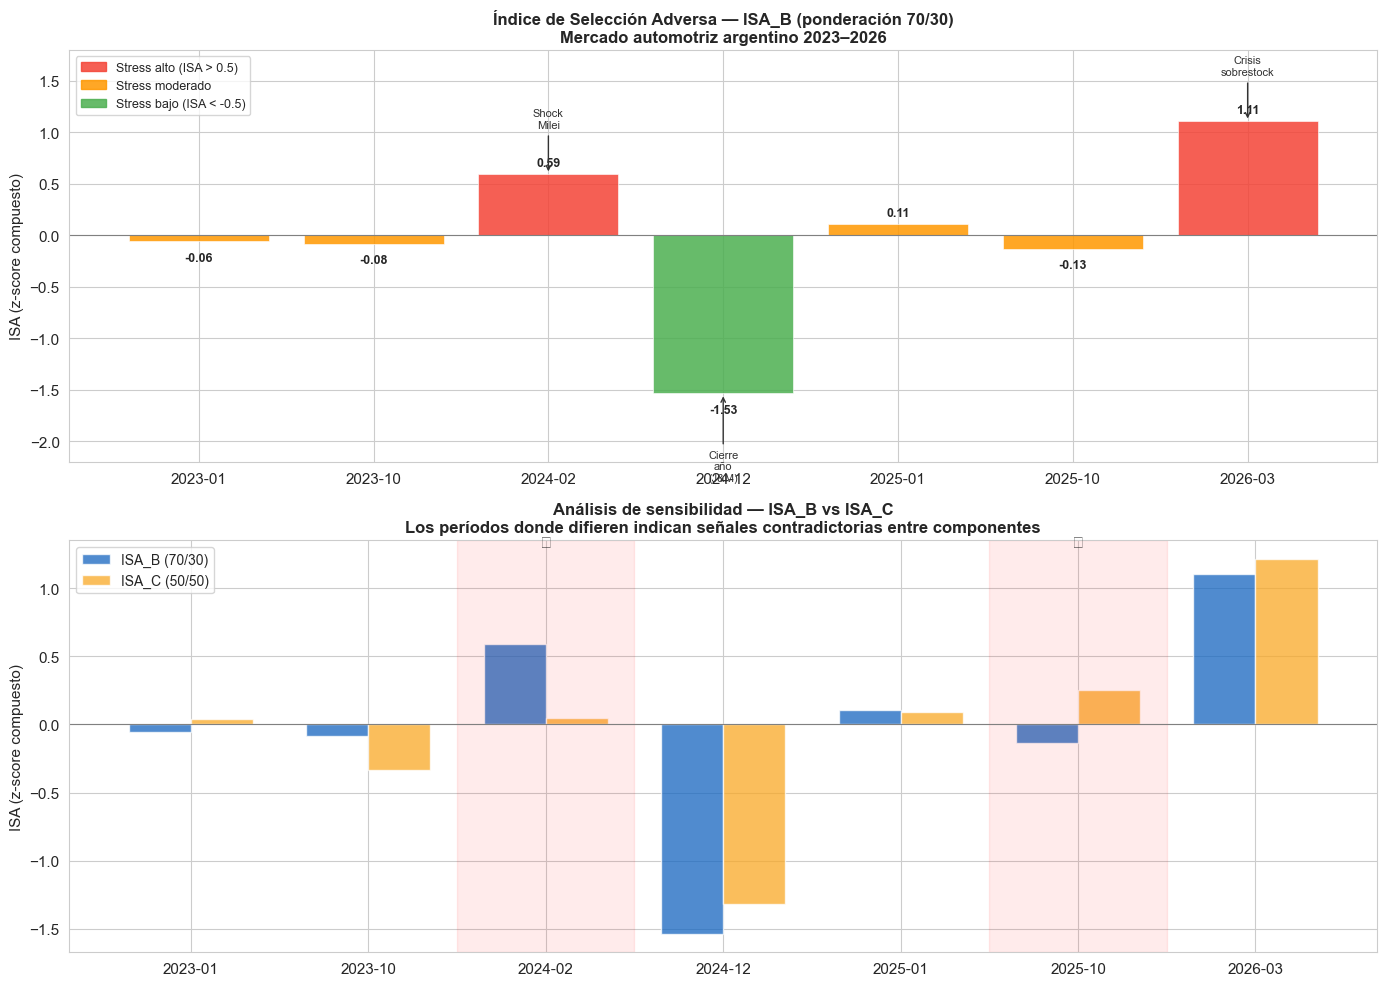

Gráfico guardado.


In [9]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

periodos_str = metricas['periodo'].astype(str)

# ---- Gráfico superior — ISA_B con contexto ----
colores_barras = []
for val in metricas['ISA_B']:
    if val > 0.5:
        colores_barras.append('#F44336')   # rojo — stress alto
    elif val < -0.5:
        colores_barras.append('#4CAF50')   # verde — stress bajo
    else:
        colores_barras.append('#FF9800')   # naranja — stress moderado

bars = axes[0].bar(
    periodos_str,
    metricas['ISA_B'],
    color=colores_barras,
    alpha=0.85,
    edgecolor='white',
    linewidth=0.5
)

# Línea de cero
axes[0].axhline(y=0, color='gray', linestyle='-', linewidth=0.8)

# Etiquetas de valor
for i, (bar, val) in enumerate(zip(bars, metricas['ISA_B'])):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        val + (0.05 if val >= 0 else -0.1),
        f'{val:.2f}',
        ha='center',
        va='bottom' if val >= 0 else 'top',
        fontsize=9,
        fontweight='bold'
    )

# Anotaciones de eventos
eventos = {
    '2024-02': ('Shock\nMilei', 0.45),
    '2024-12': ('Cierre\naño\n(J&M)', -0.85),
    '2026-03': ('Crisis\nsobrestock', 0.45)
}

for periodo, (texto, offset) in eventos.items():
    idx = metricas[metricas['periodo'].astype(str) == periodo].index[0]
    val = metricas.loc[idx, 'ISA_B']
    axes[0].annotate(
        texto,
        xy=(idx, val),
        xytext=(idx, val + offset),
        fontsize=8,
        ha='center',
        color='#333333',
        arrowprops=dict(arrowstyle='->', color='#333333', lw=1)
    )

axes[0].set_title(
    'Índice de Selección Adversa — ISA_B (ponderación 70/30)\n'
    'Mercado automotriz argentino 2023–2026',
    fontsize=12,
    fontweight='bold'
)
axes[0].set_ylabel('ISA (z-score compuesto)')
axes[0].set_ylim(-2.2, 1.8)


# Leyenda manual
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#F44336', alpha=0.85, label='Stress alto (ISA > 0.5)'),
    Patch(color='#FF9800', alpha=0.85, label='Stress moderado'),
    Patch(color='#4CAF50', alpha=0.85, label='Stress bajo (ISA < -0.5)')
]
axes[0].legend(handles=leyenda, loc='upper left', fontsize=9)

# ---- Gráfico inferior — comparación B vs C ----
x = np.arange(len(periodos_str))
width = 0.35

axes[1].bar(x - width/2, metricas['ISA_B'], width,
            label='ISA_B (70/30)', color='#1565C0', alpha=0.75)
axes[1].bar(x + width/2, metricas['ISA_C'], width,
            label='ISA_C (50/50)', color='#F9A825', alpha=0.75)

axes[1].axhline(y=0, color='gray', linestyle='-', linewidth=0.8)
axes[1].set_xticks(x)
axes[1].set_xticklabels(periodos_str)
axes[1].set_title(
    'Análisis de sensibilidad — ISA_B vs ISA_C\n'
    'Los períodos donde difieren indican señales contradictorias entre componentes',
    fontsize=12,
    fontweight='bold'
)
axes[1].set_ylabel('ISA (z-score compuesto)')
axes[1].legend(fontsize=10)

# Marcar períodos sensibles
for periodo in ['2024-02', '2025-10']:
    idx = list(periodos_str).index(periodo)
    axes[1].axvspan(idx - 0.5, idx + 0.5, alpha=0.08, color='red')
    axes[1].text(idx, 1.3, '⚠', ha='center', fontsize=12)

plt.tight_layout()
plt.savefig(
    '../reports/figures/05_indice_seleccion_adversa.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()
print("Gráfico guardado.")

---
### Lectura del gráfico

**Gráfico superior:** nivel de stress por período según ISA_B (versión principal).
Rojo = stress alto. Verde = stress bajo. Las anotaciones marcan los eventos 
macroeconómicos que explican cada pico.

**Gráfico inferior:** comparación entre ISA_B e ISA_C. 
Las zonas sombreadas en rojo señalan los dos períodos donde 
las versiones difieren — los que tienen señales contradictorias 
entre componentes.

---
## Tabla resumen — Síntesis del proyecto

Integración de métricas base, índice ISA y contexto 
macroeconómico en una tabla única de referencia.

In [10]:
# Tabla resumen integrada
contexto = {
    '2023-01': 'Línea de base — mercado sin shock',
    '2023-10': 'Incertidumbre electoral — PASO',
    '2024-02': 'Shock Milei — devaluación 54%',
    '2024-12': 'Cierre año — efecto Jensen & Meckling',
    '2025-01': 'Reequilibrio — record ventas 0km',
    '2025-10': 'Estabilización — desregulación importaciones',
    '2026-03': 'Crisis sobrestock — guerra de precios 0km'
}

resumen = metricas[['periodo', 'total', 'antiguedad_media', 
                      'pct_proto21', 'pct_jovenes', 
                      'ISA_B', 'rank_B']].copy()

resumen['contexto'] = resumen['periodo'].astype(str).map(contexto)
resumen.columns = [
    'Período', 'Transferencias', 'Antigüedad media',
    '% Protocolo 21', '% Vehículos 0-3 años',
    'ISA (70/30)', 'Rank stress', 'Contexto'
]

# Formateo
resumen['Transferencias'] = resumen['Transferencias'].apply(lambda x: f"{x:,}")
resumen['Antigüedad media'] = resumen['Antigüedad media'].apply(lambda x: f"{x:.2f}")
resumen['% Protocolo 21'] = resumen['% Protocolo 21'].apply(lambda x: f"{x:.1f}%")
resumen['% Vehículos 0-3 años'] = resumen['% Vehículos 0-3 años'].apply(lambda x: f"{x:.1f}%")
resumen['ISA (70/30)'] = resumen['ISA (70/30)'].apply(lambda x: f"{x:.2f}")

pd.set_option('display.max_columns', 10)
pd.set_option('display.width', 120)
pd.set_option('display.max_colwidth', 40)
print("TABLA RESUMEN — MERCADO DE LIMONES ARGENTINOS 2023-2026")
print("="*80)
print(resumen.to_string(index=False))
pd.reset_option('display.max_columns')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

TABLA RESUMEN — MERCADO DE LIMONES ARGENTINOS 2023-2026
Período Transferencias Antigüedad media % Protocolo 21 % Vehículos 0-3 años ISA (70/30)  Rank stress                                     Contexto
2023-01        132,129            14.21          40.7%                 6.9%       -0.06            4            Línea de base — mercado sin shock
2023-10        140,402            14.47          39.3%                 8.2%       -0.08            5               Incertidumbre electoral — PASO
2024-02        105,408            15.05          38.9%                 8.1%        0.59            2                Shock Milei — devaluación 54%
2024-12        159,667            13.34          39.5%                10.2%       -1.53            7        Cierre año — efecto Jensen & Meckling
2025-01        169,213            14.39          40.4%                 7.0%        0.11            3             Reequilibrio — record ventas 0km
2025-10        165,683            13.95          41.7%              

---
## Hallazgo integrador — Lo que el índice cuenta

### Ranking de stress por selección adversa (ISA_B)

| Rank | Período | ISA | Evento central |
|---|---|---|---|
| 1° | 2026-03 | +1.11 | Crisis sobrestock — máximo stress actual |
| 2° | 2024-02 | +0.59 | Shock Milei — retención máxima |
| 3° | 2025-01 | +0.11 | Reequilibrio post-liquidación |
| 4° | 2023-01 | -0.06 | Línea de base |
| 5° | 2023-10 | -0.08 | Incertidumbre electoral leve |
| 6° | 2025-10 | -0.13 | Estabilización |
| 7° | 2024-12 | -1.53 | Menor stress — liquidación fin de año |

### Conclusión central

El Índice de Selección Adversa muestra que el mercado 
automotriz argentino de usados opera bajo condiciones 
de selección adversa de intensidad variable, con dos 
patrones claramente diferenciados:

**Patrón 1 — Stress por retención (Akerlof):**
En shocks macroeconómicos (devaluación, incertidumbre, 
sobrestock), los propietarios de vehículos de mejor 
calidad los retienen. El mercado secundario se deteriora: 
la antigüedad promedio sube y la participación de 
vehículos recientes cae. El ISA sube.

**Patrón 2 — Alivio por liquidación (Jensen & Meckling):**
En cierres de año, la presión de objetivos comerciales 
fuerza a los vendedores a liberar sus mejores unidades 
primero. La calidad promedio del mercado mejora 
transitoriamente. El ISA cae.

**El mercado en 2026:**
Marzo 2026 registra el ISA más alto de la serie, 
consistente con la crisis de sobrestock actual. 
La selección adversa no es un fenómeno histórico 
en este mercado. Es el estado presente.